<a href="https://colab.research.google.com/github/Muhammad-Musharraf/Classification-of-Fashion-of-fashion_minst_using_CNN/blob/main/Classification_of_Fashion_of_fashion_minst_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from PIL import Image
from sklearn.model_selection import train_test_split
import random

In [56]:
(x_train,y_train),(x_test,y_test)=keras.datasets.fashion_mnist.load_data()

Image: AxesImage(shape=(28, 28))
Label: 5


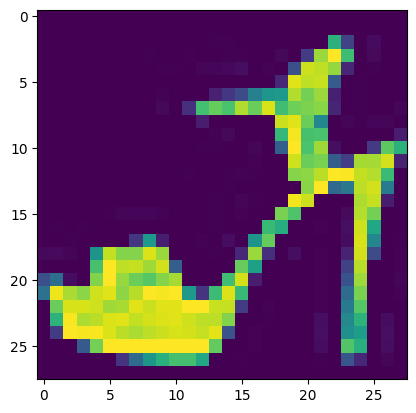

In [57]:
print(f"Image: {plt.imshow(x_train[9])}")

print(f"Label: {y_train[9]}")

Image:AxesImage(shape=(28, 28))
Label: 5


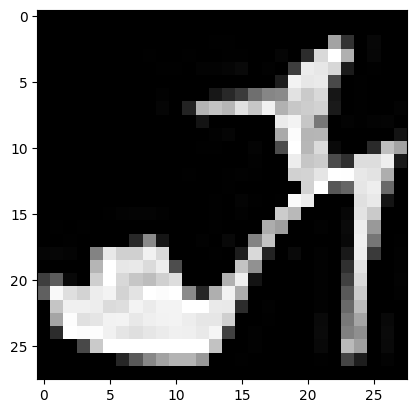

In [58]:
print(f"Image:{plt.imshow(x_train[9],cmap='gray')}")

print(f"Label: {y_train[9]}")

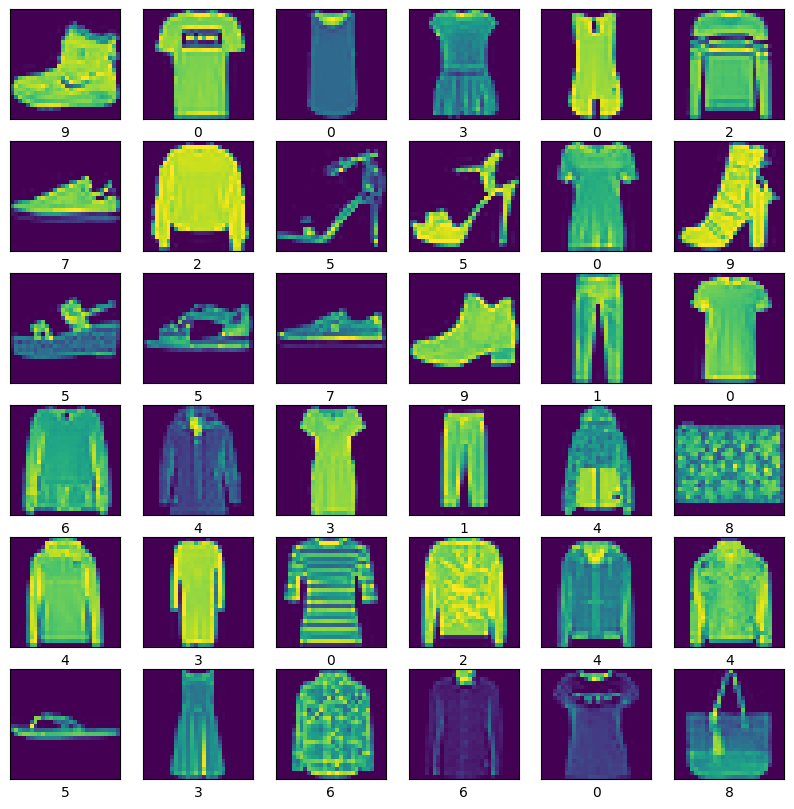

In [59]:
plt.figure(figsize=(10,10))
for i in range(36):
  plt.subplot(6,6,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(x_train[i])
  plt.xlabel(y_train[i])
plt.show()


# Exploratory Data Analysis (EDA)

In [60]:
print(f"""We Have {len(x_train)} images in Train data and  {len(x_test)} images in Test data.
Similarly,
We Have {len(y_train)} labels in Train data and {len(y_test)} labels in Test data.

The size of Each image Present in Train and Test data is {x_train[0].shape}""")

We Have 60000 images in Train data and  10000 images in Test data.
Similarly,
We Have 60000 labels in Train data and 10000 labels in Test data.

The size of Each image Present in Train and Test data is (28, 28)


In [61]:
x_train.shape

(60000, 28, 28)

In [62]:
x_test.shape

(10000, 28, 28)

In [63]:
y_train.shape

(60000,)

In [64]:
y_test.shape

(10000,)

# Print Random Images from Data

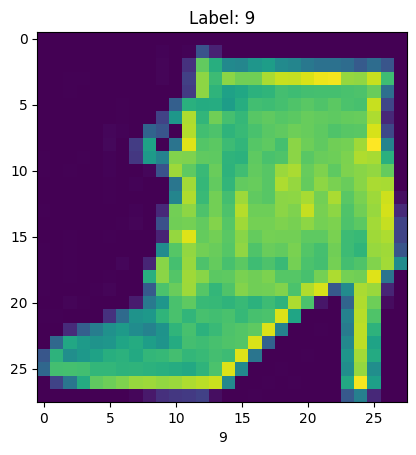

In [65]:
random_image=random.randint(0,len(x_train))
plt.imshow(x_train[random_image])
plt.title(f"Label: {y_train[random_image]}")
plt.xlabel(y_train[random_image])
plt.show()

# Displaying The Image With Their Each Pixel Value

Image:


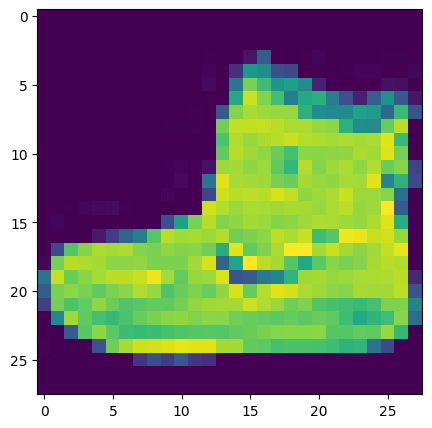

Pixel Values:
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0   0   1   4   0   0   0   0   1   1   0 
  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62  54   0   0   0   1   3   4   0   0   3 
  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134 144 123  23   0   0   0   0  12  10   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178 107 156 161 109  64  23  77 130  72  15 
  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216 216 163 127 121 122 146 141  88 172  66 
  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 232 233 229 223 223 21

In [66]:
print("Image:")
plt.figure(figsize=(5,5))
plt.imshow(x_train[0])
plt.show()
print("Pixel Values:")

for row in x_train[0]:
  for pixel in row:
    print("{:3}".format(pixel),end=" ")
  print()


In [67]:
x_train=x_train.reshape(x_train.shape+(1,))
x_test=x_test.reshape(x_test.shape+(1,))

x_train.shape,x_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

# Normalizing The Data
Neural network performs better on normalized data.Normalization turns the data into the same scale, in our case, between 0 and 1.

In the case of images, the normalization depends upon the maximum value of the pixels which is 8 bit. In simplt words, each pixle value must be present between (0-255) range.So we directly take the ratio of the images to 255 ,that sets all the images pixles values in between 0 to 1 that is more suitable for model to perform accuratly.

In [68]:
x_train=x_train/255.0
x_test=x_test/255.0

# Change DataTypes

In [69]:
x_train=x_train.astype("float32")
x_test=x_test.astype("float32")

# Displaying The Image With Their Each Pixel Value After Normalization

Image:


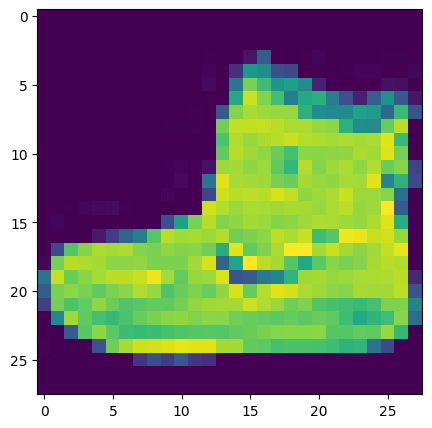

Pixel Values:
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.004 0.000 0.000 0.051 0.286 0.000 0.000 0.004 0.016 0.000 0.000 0.000 0.000 0.004 0.004 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.012 0.000 0.141 0.533 0.498 0.243 0.212 0.000 0.000 0.000 0.004 0.012 0.016 0.000 0.000 0.012 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.024 0.000 0.400 0.800 0.690 0.525 0.565 0.482 0.090 0.000 0.000 0.0

/tmp/ipykernel_1394/341494438.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("{:0.3f}".format(float(pixel)),end=" ")


In [70]:
print("Image:")
plt.figure(figsize=(5,5))
plt.imshow(x_train[0])
plt.show()
print("Pixel Values:")

for row in x_train[0]:
  for pixel in row:
    print("{:0.3f}".format(float(pixel)),end=" ")
  print()

# Data Modeling With CNN

In [71]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(28, 28, 1)),

    # Block 1
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    tf.keras.layers.MaxPool2D(),        # 28×28 → 14×14
    tf.keras.layers.Dropout(0.25),

    # Block 2
    tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    tf.keras.layers.MaxPool2D(),        # 14×14 → 7×7
    tf.keras.layers.Dropout(0.25),

    # Block 3
    tf.keras.layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(),        # 7×7 → 3×3
    tf.keras.layers.Dropout(0.25),

    # Classifier head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [72]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 438,506 (1.67 MB)

 Trainable params: 437,546 (1.67 MB)

 Non-trainable params: 960 (3.75 KB)

In [73]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [74]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

In [75]:
history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]

)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7765 - loss: 0.6355 - val_accuracy: 0.8518 - val_loss: 0.3951
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8616 - loss: 0.3766 - val_accuracy: 0.8633 - val_loss: 0.3607
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8846 - loss: 0.3192 - val_accuracy: 0.8962 - val_loss: 0.2883
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8955 - loss: 0.2857 - val_accuracy: 0.9065 - val_loss: 0.2498
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9031 - loss: 0.2650 - val_accuracy: 0.9057 - val_loss: 0.2531
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9075 - loss: 0.2530 - val_accuracy: 0.9112 - val_loss: 0.2361
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9137 - loss: 0.2375 - val_accuracy: 0.9146 - val_loss: 0.2238
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9165 - loss: 0.2288 - val_accuracy: 0

# Graphical representation of Accuracy & Loss

# 1.Loss

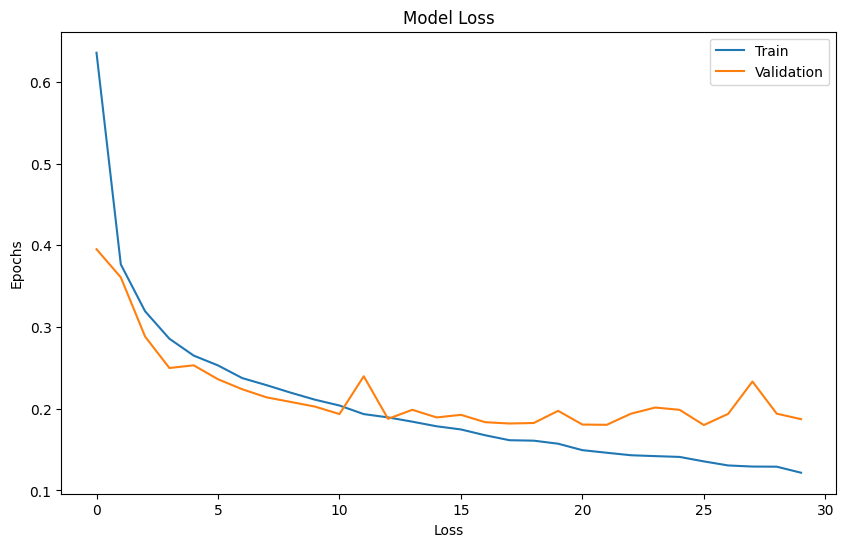

In [76]:
plt.figure(figsize=(10,6))
plt.xlabel("Loss")
plt.ylabel("Epochs")
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'],loc='upper right')
plt.title('Model Loss')
plt.show()

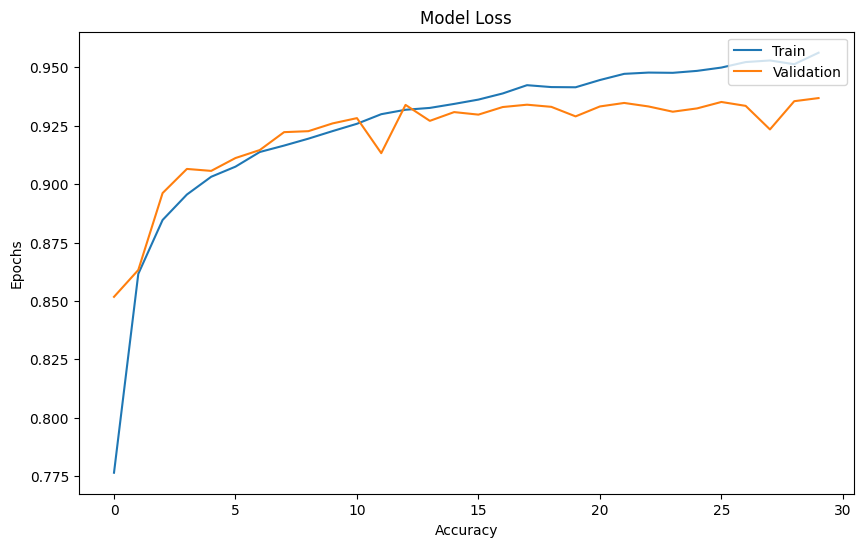

In [77]:
plt.figure(figsize=(10,6))
plt.xlabel("Accuracy")
plt.ylabel("Epochs")
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'],loc='upper right')
plt.title('Model Loss')
plt.show()

#Model Evaluation For Loss Accuracy On Test Data

In [78]:
loss,accuracy=model.evaluate(x_test,y_test)

print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9328 - loss: 0.1984
Loss: 0.19843052327632904
Accuracy: 0.9327999949455261
